In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sold = pd.read_csv("/Users/seanshih/Desktop/IDX/CRMLS_Sold_All.csv")

/var/folders/5h/bxf_bvns78z4pt8s0drk3kcc0000gn/T/ipykernel_33535/939414945.py:5: DtypeWarning: Columns (0,1,9,78,79,80,81,82) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("/Users/seanshih/Desktop/IDX/CRMLS_Sold_All.csv")


In [123]:
print(sold.columns)

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [126]:
sold.shape

(591733, 84)

In [128]:
sold.dtypes

BuyerAgentAOR                   object
ListAgentAOR                    object
Flooring                        object
ViewYN                          object
WaterfrontYN                    object
                                ...   
lonfilled                       object
OriginatingSystemName           object
OriginatingSystemSubName        object
BuyerAgencyCompensationType     object
BuyerAgencyCompensation        float64
Length: 84, dtype: object

In [130]:
#filer to residential
print(sold["PropertyType"].value_counts())

# Filter to residential only
sold = sold[sold["PropertyType"] == "Residential"]
print(f"\nFiltered to {len(sold):,} residential records")

PropertyType
Residential            397603
ResidentialLease       135617
Land                    19345
ManufacturedInPark      16082
ResidentialIncome       15865
CommercialSale           3714
CommercialLease          3104
BusinessOpportunity       403
Name: count, dtype: int64

Filtered to 397,603 residential records


In [132]:
#find percent of missing data in each column and put in a new dataframe

missing = sold.isnull().sum()
missing_pct = (missing / len(sold) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)


In [134]:
missing_df

,missing_count,missing_pct
CoveredSpaces,397603,100.0
MiddleOrJuniorSchoolDistrict,397603,100.0
AboveGradeFinishedArea,397603,100.0
FireplacesTotal,397603,100.0
TaxYear,397603,100.0
...,...,...
ListOfficeName,0,0.0
BedroomsTotal,11,0.0
ListingId,0,0.0
ListingKeyNumeric,0,0.0


In [136]:
#from the new dataframe, find any columns with greater missing % than 90%
cols_to_drop = missing_df[missing_df["missing_pct"] > 90].index.tolist()

print(f"Columns with >90% missing ({len(cols_to_drop)}):\n")
for col in cols_to_drop:
    print(f"  {col:40s} {missing_df.loc[col, 'missing_pct']}%")

Columns with >90% missing (17):

  CoveredSpaces                            100.0%
  MiddleOrJuniorSchoolDistrict             100.0%
  AboveGradeFinishedArea                   100.0%
  FireplacesTotal                          100.0%
  TaxYear                                  100.0%
  ElementarySchoolDistrict                 100.0%
  BusinessType                             100.0%
  TaxAnnualAmount                          100.0%
  WaterfrontYN                             99.94%
  BelowGradeFinishedArea                   99.42%
  BasementYN                               98.04%
  LotSizeDimensions                        95.14%
  BuilderName                              95.08%
  BuildingAreaTotal                        93.01%
  CoBuyerAgentFirstName                    90.94%
  OriginatingSystemSubName                 90.13%
  OriginatingSystemName                    90.13%


In [138]:
high_missing = missing_df[missing_df["missing_pct"] > 90]
print(f"Total columns >90% missing: {len(high_missing)}")
print(high_missing)

Total columns >90% missing: 17
                              missing_count  missing_pct
CoveredSpaces                        397603       100.00
MiddleOrJuniorSchoolDistrict         397603       100.00
AboveGradeFinishedArea               397603       100.00
FireplacesTotal                      397603       100.00
TaxYear                              397603       100.00
ElementarySchoolDistrict             397603       100.00
BusinessType                         397603       100.00
TaxAnnualAmount                      397603       100.00
WaterfrontYN                         397355        99.94
BelowGradeFinishedArea               395313        99.42
BasementYN                           389826        98.04
LotSizeDimensions                    378282        95.14
BuilderName                          378056        95.08
BuildingAreaTotal                    369810        93.01
CoBuyerAgentFirstName                361576        90.94
OriginatingSystemSubName             358351        90.13


In [140]:
sold = sold.drop(columns=cols_to_drop)
#drop the columns with missing % greater than 90%
#dropped 17 columns 

In [142]:
sold.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince',

In [144]:
#separate the market fields from metadata after dropping the >90% null columns
market_fields = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
                 "LotSizeAcres", "LotSizeSquareFeet", "LotSizeArea",
                 "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket",
                 "YearBuilt", "Stories", "Levels", "GarageSpaces", "ParkingTotal",
                 "AssociationFee", "AssociationFeeFrequency", "FireplaceYN",
                 "PoolPrivateYN", "AttachedGarageYN", "NewConstructionYN",
                 "MainLevelBedrooms", "BuildingAreaTotal",
                 "City", "CountyOrParish", "PostalCode", "StateOrProvince",
                 "PropertyType", "PropertySubType", "UnparsedAddress",
                 "Latitude", "Longitude", "Flooring", "ViewYN",
                 "CloseDate", "ListingContractDate", "PurchaseContractDate"]

metadata_fields = [col for col in sold.columns if col not in market_fields]

print(f"MARKET ANALYSIS FIELDS ({len(market_fields)}):")
print(market_fields)

print(f"\nMETADATA FIELDS ({len(metadata_fields)}):")
print(metadata_fields)

MARKET ANALYSIS FIELDS (37):
['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'LotSizeSquareFeet', 'LotSizeArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt', 'Stories', 'Levels', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'AssociationFeeFrequency', 'FireplaceYN', 'PoolPrivateYN', 'AttachedGarageYN', 'NewConstructionYN', 'MainLevelBedrooms', 'BuildingAreaTotal', 'City', 'CountyOrParish', 'PostalCode', 'StateOrProvince', 'PropertyType', 'PropertySubType', 'UnparsedAddress', 'Latitude', 'Longitude', 'Flooring', 'ViewYN', 'CloseDate', 'ListingContractDate', 'PurchaseContractDate']

METADATA FIELDS (31):
['BuyerAgentAOR', 'ListAgentAOR', 'ListingKey', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'ListingKeyNumeric', 'MLSAreaMa

In [146]:
sold.head

<bound method NDFrame.head of            BuyerAgentAOR      ListAgentAOR           Flooring ViewYN  \
0                Arcadia           Arcadia                NaN  False   
7       CaliforniaDesert  CaliforniaDesert               Tile   True   
8                 Laguna            Laguna               Wood   True   
9       PacificSouthwest  PacificSouthwest                NaN   True   
10      TheInlandGateway  TheInlandGateway  Carpet,Stone,Tile   True   
...                  ...               ...                ...    ...   
591689               NaN               NaN                NaN   True   
591702               NaN               NaN               Wood   True   
591703               NaN               NaN                NaN   True   
591713               NaN               NaN        Carpet,Tile   True   
591727               NaN               NaN                NaN  False   

       PoolPrivateYN  OriginalListPrice  ListingKey  \
0              False          1130000.0   53833872

In [148]:
numeric_cols = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
                "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
                "DaysOnMarket", "YearBuilt"]

sold[numeric_cols].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,3.976010e+05,3.976030e+05,3.968820e+05,3.973740e+05,3.662390e+05,397592.000000,397534.000000,397603.000000,397247.000000
mean,1.185616e+06,1.138630e+06,1.224737e+06,1.904351e+03,6.855894e+01,3.200200,2.533185,37.336788,1978.567921
std,5.922380e+06,1.353707e+06,6.779804e+06,2.701781e+04,1.632724e+04,1.067419,1.135979,53.539245,26.272785
min,0.000000e+00,5.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-288.000000,1776.000000
25%,5.750000e+05,5.750000e+05,5.850000e+05,1.247000e+03,1.200000e-01,3.000000,2.000000,8.000000,1960.000000
50%,8.200000e+05,8.150000e+05,8.250000e+05,1.641000e+03,1.663000e-01,3.000000,2.000000,19.000000,1979.000000
75%,1.300000e+06,1.295000e+06,1.299000e+06,2.217000e+03,2.724000e-01,4.000000,3.000000,48.000000,1999.000000
max,9.895000e+08,1.375000e+08,1.390000e+09,1.702132e+07,7.810698e+06,45.000000,175.000000,12430.000000,2026.000000


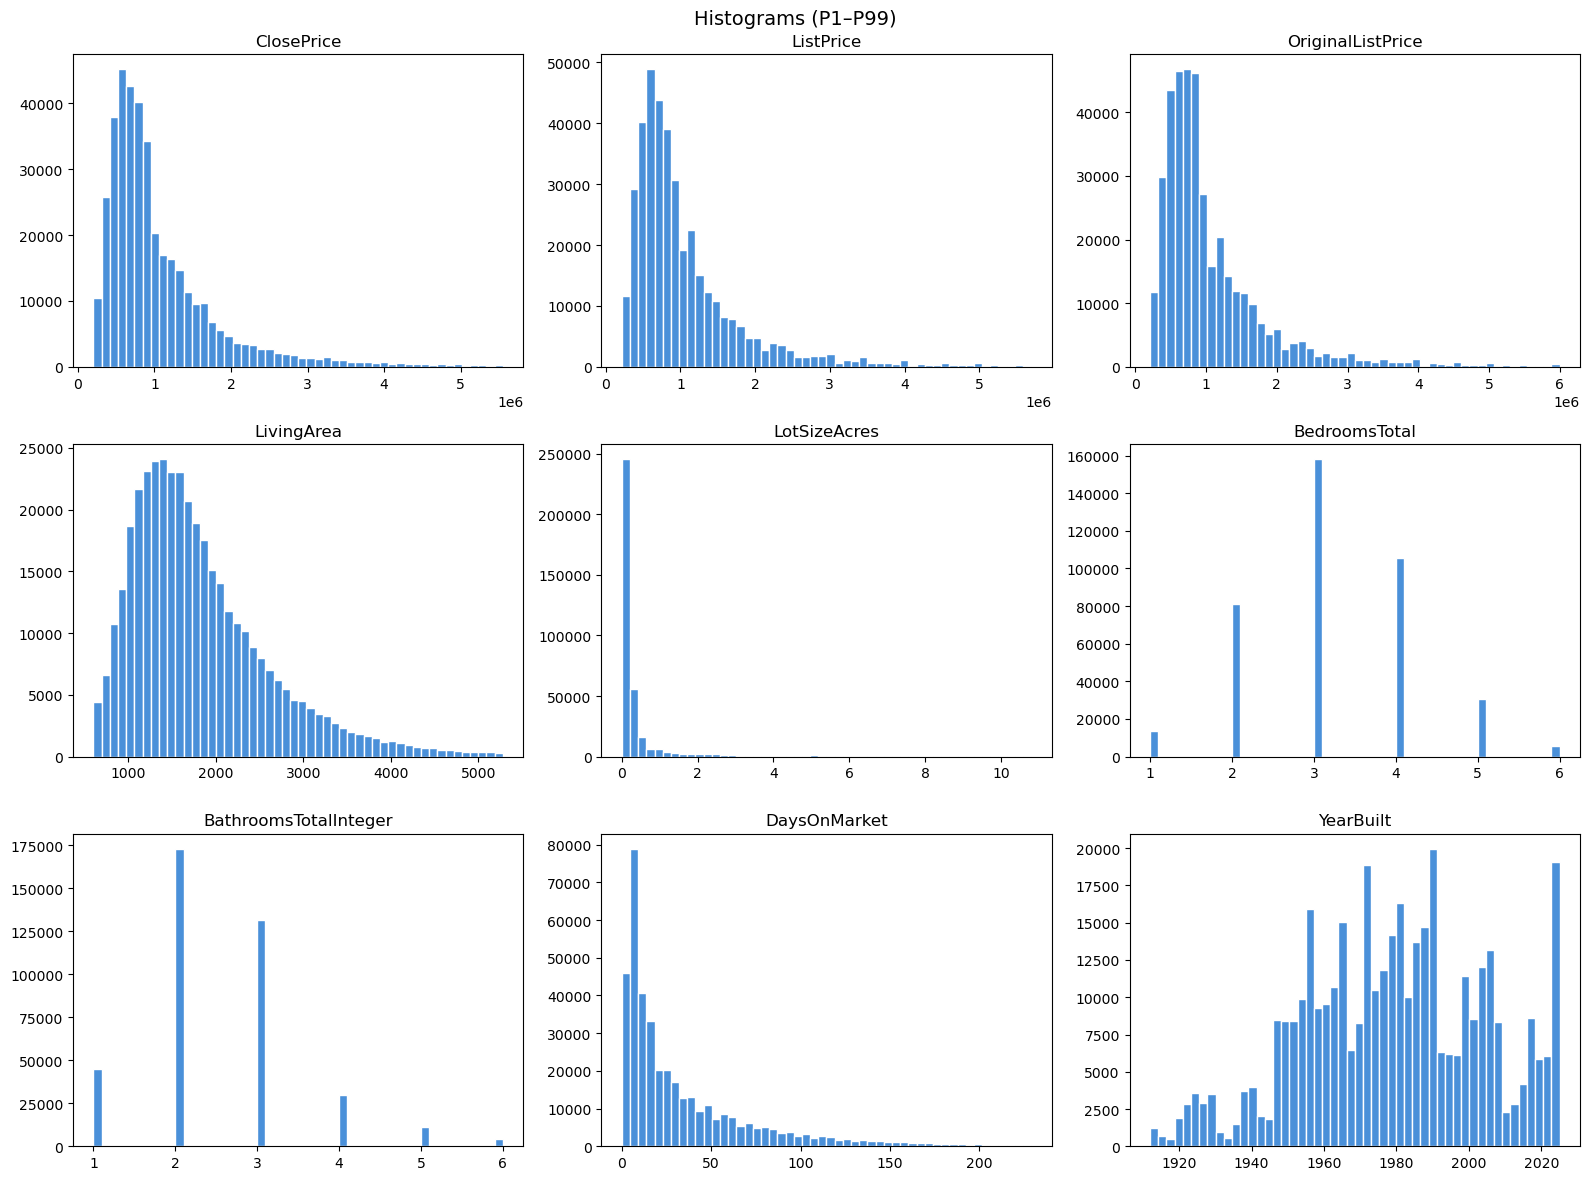

In [150]:
#create histograms 
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = sold[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    clipped = data[(data >= lo) & (data <= hi)]
    
    axes[i].hist(clipped, bins=50, edgecolor="white", color="#4a90d9")
    axes[i].set_title(col)

plt.suptitle("Histograms (P1–P99)", fontsize=14)
plt.tight_layout()
plt.show()

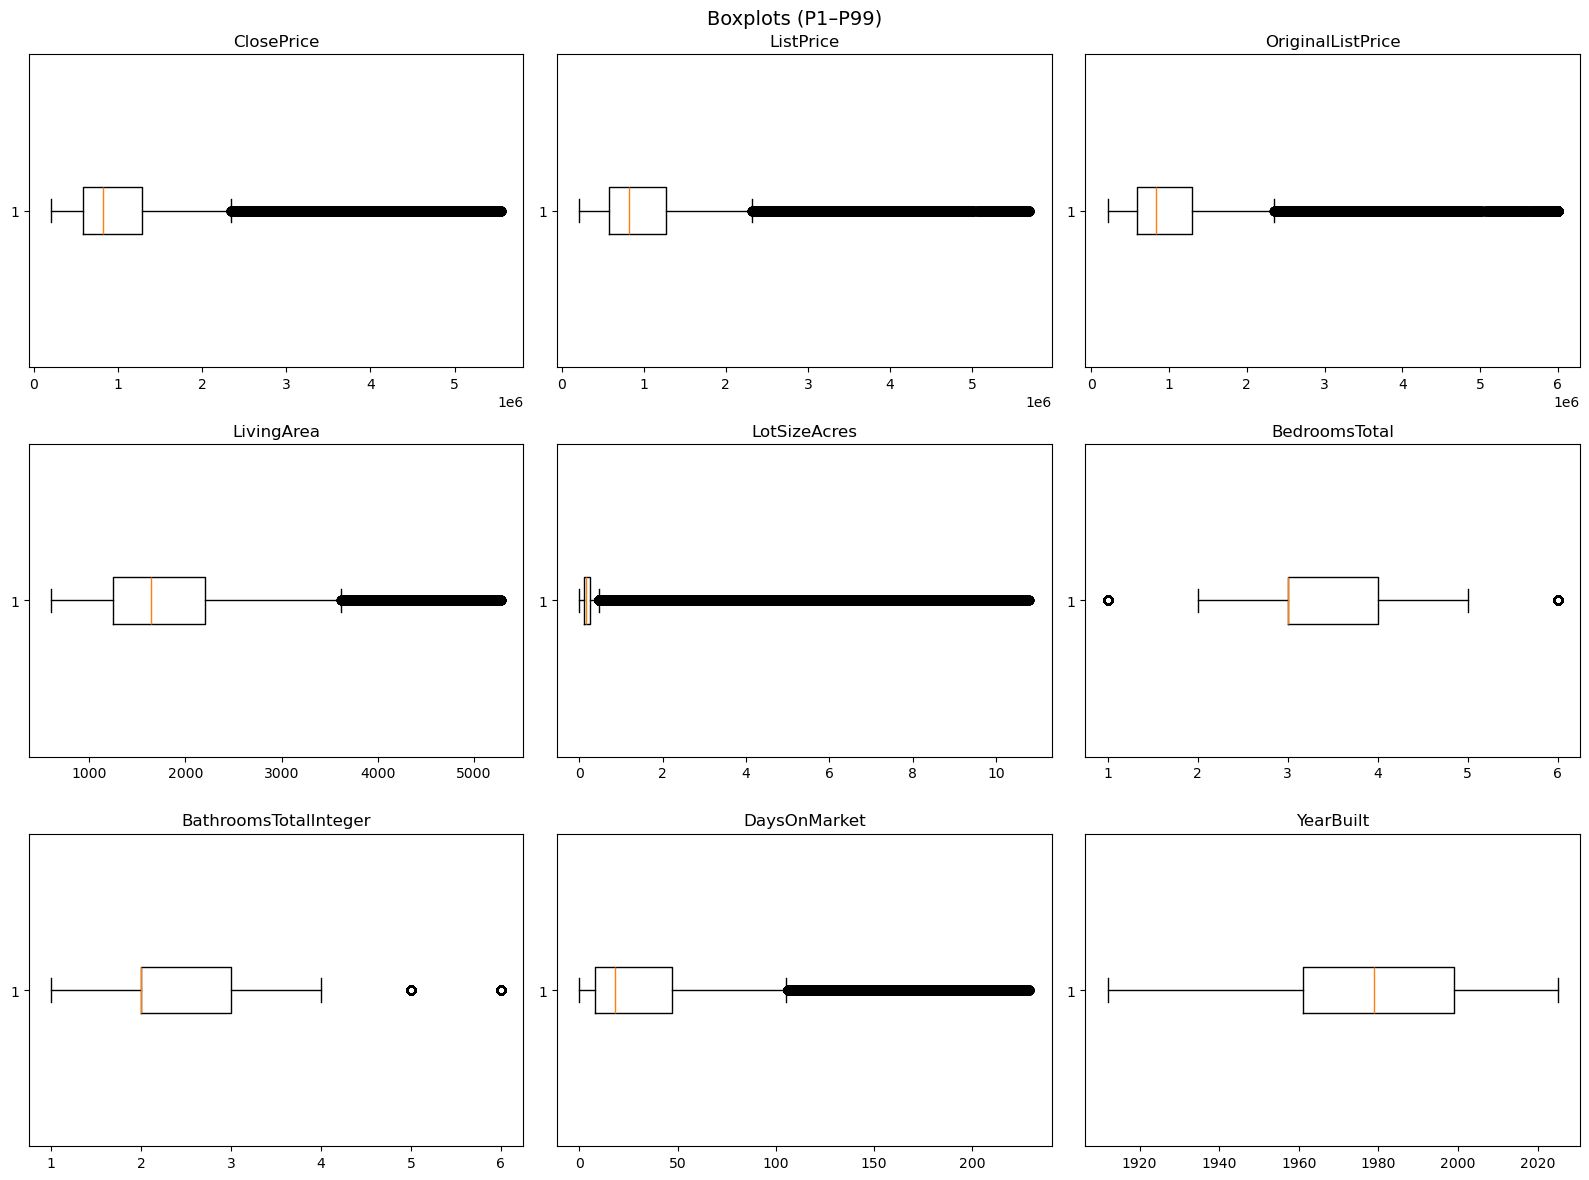

In [152]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = sold[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    clipped = data[(data >= lo) & (data <= hi)]
    
    axes[i].boxplot(clipped, vert=False)
    axes[i].set_title(col)

plt.suptitle("Boxplots (P1–P99)", fontsize=14)
plt.tight_layout()
plt.show()

#Close Price, ListPrice, and OriginalListPrice are all heavily skewed to the right, the right side thick lines suggest that there are some 
#extreme prices for luxury homes in the residential areas bringing mean upwards 

#LivingArea is also right skewed as well with most homes being around the 1000-2000 sqft range 
#LotSize is almost close to zero with most of the residential spaces being close to 0 in plot size

#bedrooms and bathrooms are pretty uniform 
#days on market is skewed right with some homes selling between 0-48 days but some even at the 200 mark 
#years built is symmetrical

In [154]:
#outliers count
for col in numeric_cols:
    data = sold[col].dropna()
    p01, p99 = data.quantile(0.01), data.quantile(0.99)
    outliers = data[(data < p01) | (data > p99)]
    print(f"{col:30s} {len(outliers):>6,} outliers")

ClosePrice                      7,938 outliers
ListPrice                       7,949 outliers
OriginalListPrice               7,787 outliers
LivingArea                      7,932 outliers
LotSizeAcres                    3,663 outliers
BedroomsTotal                   2,882 outliers
BathroomsTotalInteger           3,031 outliers
DaysOnMarket                    4,019 outliers
YearBuilt                       3,954 outliers


In [156]:
sold.to_csv("/Users/seanshih/Desktop/CRMLS_Sold_Residential.csv", index=False)